In [1]:
import geopandas as gpd

# 1. Leer el archivo Shapefile
ruta_shp = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\red_vial.shp"
gdf = gpd.read_file(ruta_shp)

# 2. (Opcional) Eliminar la geometría si solo quieres la tabla de atributos
# Si no haces esto, la geometría se guardará como texto en el CSV
# gdf = gdf.drop(columns='geometry')

# 3. Guardar el GeoDataFrame como archivo CSV
ruta_csv = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\red_vial.csv"
gdf.to_csv(ruta_csv, index=False, encoding='utf-8')

print("¡Conversión completada!")

¡Conversión completada!


In [2]:
import pandas as pd

# 1. Ruta de tu archivo CSV gigante
ruta_csv = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\red_vial.csv"

# 2. Definir cuántas filas quieres por cada archivo nuevo (1 millón es seguro para Excel)
filas_por_archivo = 1000000

# 3. Leer y dividir
numero_parte = 1
# read_csv con chunksize lee el archivo por bloques en lugar de todo a la vez
for pedazo in pd.read_csv(ruta_csv, chunksize=filas_por_archivo):
    nombre_salida = f"archivo_dividido_parte_{numero_parte}.csv"
    pedazo.to_csv(nombre_salida, index=False, encoding='utf-8')
    print(f"Guardado: {nombre_salida}")
    numero_parte += 1

print("¡División completada!")

Guardado: archivo_dividido_parte_1.csv
Guardado: archivo_dividido_parte_2.csv
Guardado: archivo_dividido_parte_3.csv
Guardado: archivo_dividido_parte_4.csv
¡División completada!


In [ ]:
import geopandas as gpd

# 1. Leer el archivo
ruta_shp = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\red_vial.shp"
gdf = gpd.read_file(ruta_shp)

# 2. Generar el mapa interactivo
# Nota: Esto puede tardar un poco si tu archivo es gigante (millones de filas)
mapa = gdf.explore(
    cmap="viridis", # Paleta de colores
    tooltip=True    # Muestra los datos al pasar el mouse
)

# 3. Guardar el mapa como un archivo de internet
mapa.save("mapa_interactivo.html")
print("¡Listo! Ve a tu carpeta y dale doble clic a 'mapa_interactivo.html'")

In [1]:
import geopandas as gpd

# 1. Leer el archivo Shapefile
ruta_shp = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\22mun.shp"
gdf = gpd.read_file(ruta_shp)

# 2. (Opcional) Eliminar la geometría si solo quieres la tabla de atributos
# Si no haces esto, la geometría se guardará como texto en el CSV
# gdf = gdf.drop(columns='geometry')

# 3. Guardar el GeoDataFrame como archivo CSV
ruta_csv = "C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\22mun.csv"
gdf.to_csv(ruta_csv, index=False, encoding='utf-8')

print("¡Conversión completada!")

¡Conversión completada!


In [7]:
import geopandas as gpd

# 1. Cargar los polígonos de los municipios de Querétaro
municipios_qro = gpd.read_file(r"C:\Users\Yaveh\Desktop\Investigación Manuel\22mun.shp", engine="pyogrio")

# 2. Cargar las carreteras y los puntos de interés
# (Ejemplo asumiendo que estaban dentro de 'conjunto_de_datos')
ruta_carreteras = r"C:\Users\Yaveh\Desktop\Investigación Manuel\red_vial.shp"
ruta_puntos = r"C:\Users\Yaveh\Desktop\Investigación Manuel\sitio_de_interes.shp"

carreteras_nacional = gpd.read_file(ruta_carreteras, engine="pyogrio")
puntos_interes_nacional = gpd.read_file(ruta_puntos, engine="pyogrio")

print("Archivos cargados. Verificando sistemas de coordenadas (CRS)...")

Archivos cargados. Verificando sistemas de coordenadas (CRS)...


In [8]:
import geopandas as gpd

# 1. Cargar los polígonos de los municipios de Querétaro
# Usar engine='pyogrio' hace la lectura y escritura muchísimo más rápida
municipios_qro #= #gpd.read_file("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\22mun.shp", engine="pyogrio")

# 2. Cargar las carreteras y los puntos de interés nacionales de la RNC
# Nota: Ajusta el nombre de los archivos .shp según cómo vengan en tu carpeta de la RNC
carreteras_nacional #= gpd.read_file("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\RNC\\Red_Vial.shp", engine="pyogrio")
puntos_interes_nacional #= gpd.read_file("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\RNC\\Sitios_de_Interes.shp", engine="pyogrio")

print("Archivos cargados. Verificando sistemas de coordenadas (CRS)...")

# 3. Unificar el Sistema de Coordenadas (CRS)
# Es vital que todas las capas "hablen" el mismo idioma espacial antes de cortarlas
if carreteras_nacional.crs != municipios_qro.crs:
    carreteras_nacional = carreteras_nacional.to_crs(municipios_qro.crs)
    
if puntos_interes_nacional.crs != municipios_qro.crs:
    puntos_interes_nacional = puntos_interes_nacional.to_crs(municipios_qro.crs)

print("CRS unificados. Iniciando el recorte espacial (Clip)...")

# 4. Realizar el recorte espacial (Clip)
# Esto dejará únicamente las líneas y puntos que estén dentro de los municipios de Querétaro
carreteras_qro = gpd.clip(carreteras_nacional, municipios_qro)
print(f"Carreteras recortadas: {len(carreteras_qro)} segmentos encontrados.")

puntos_interes_qro = gpd.clip(puntos_interes_nacional, municipios_qro)
print(f"Puntos de interés recortados: {len(puntos_interes_qro)} sitios encontrados.")

# 5. Guardar los resultados como nuevos Shapefiles para tenerlos aislados
carreteras_qro.to_file("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\carreteras_solo_queretaro.shp", engine="pyogrio")
puntos_interes_qro.to_file("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\puntos_interes_solo_queretaro.shp", engine="pyogrio")

# 6. Guardar las tablas de atributos a CSV (sin geometría) para Excel
carreteras_qro.drop(columns='geometry').to_csv("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\carreteras_queretaro.csv", index=False, encoding='utf-8')
puntos_interes_qro.drop(columns='geometry').to_csv("C:\\Users\\Yaveh\\Desktop\\Investigación Manuel\\puntos_interes_queretaro.csv", index=False, encoding='utf-8')

print("¡Proceso completado con éxito!")

Archivos cargados. Verificando sistemas de coordenadas (CRS)...
CRS unificados. Iniciando el recorte espacial (Clip)...
Carreteras recortadas: 47139 segmentos encontrados.
Puntos de interés recortados: 1061 sitios encontrados.
¡Proceso completado con éxito!


In [9]:
# Asumiendo que ya tienes tus recortes guardados en las variables:
# carreteras_qro y puntos_interes_qro

# 1. Guardar como Shapefile (Perfecto para GeoDa y GeoPandas)
# Al usar .to_file(), GeoPandas guarda automáticamente la geometría
ruta_salida_carreteras = r"C:\Users\Yaveh\Desktop\Investigación Manuel\carreteras_queretaro_geo.shp"
ruta_salida_puntos = r"C:\Users\Yaveh\Desktop\Investigación Manuel\puntos_interes_queretaro_geo.shp"

carreteras_qro.to_file(ruta_salida_carreteras, engine="pyogrio")
puntos_interes_qro.to_file(ruta_salida_puntos, engine="pyogrio")

print("¡Archivos Shapefile creados con éxito y listos para GeoDa!")

¡Archivos Shapefile creados con éxito y listos para GeoDa!


In [10]:
import geopandas as gpd

municipios = gpd.read_file(r"C:\Users\Yaveh\Desktop\Investigación Manuel\22mun.shp", engine="pyogrio")
carreteras = gpd.read_file(r"C:\Users\Yaveh\Desktop\Investigación Manuel\carreteras_queretaro_geo.shp", engine="pyogrio")

# Asegurar un CRS métrico proyectado (ej. UTM Zona 14N) para calcular distancias reales
municipios = municipios.to_crs(epsg=32614)
carreteras = carreteras.to_crs(epsg=32614)

# Calcular la longitud de cada segmento (en kilómetros)
carreteras['long_km'] = carreteras.geometry.length / 1000

# Unir espacialmente las carreteras con los municipios
carreteras_con_mun = gpd.sjoin(carreteras, municipios, how="inner", predicate="intersects")

# Sumar los kilómetros totales de carretera agrupados por municipio
km_por_municipio = carreteras_con_mun.groupby('index_right')['long_km'].sum()

# Añadir la nueva variable al mapa de polígonos de Querétaro
municipios['tot_km_car'] = municipios.index.map(km_por_municipio).fillna(0)

# Guardar el polígono enriquecido, regresando a coordenadas geográficas (si lo prefieres)
municipios.to_crs(epsg=4326).to_file(r"C:\Users\Yaveh\Desktop\Investigación Manuel\municipios_qro_enriquecido.shp", engine="pyogrio")

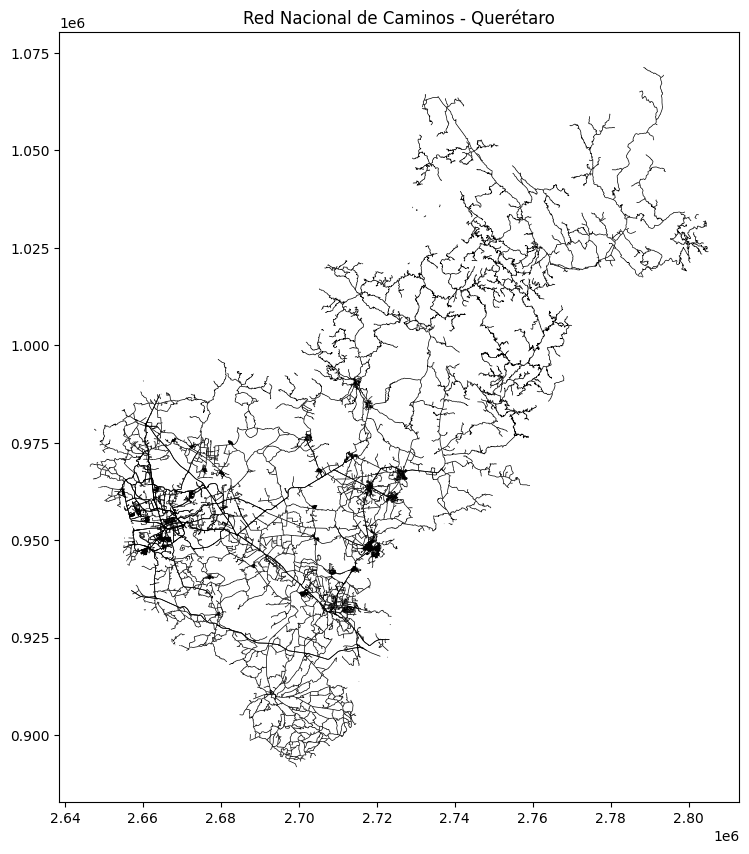

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

# GeoPandas lee geometrías de líneas perfectamente
carreteras = gpd.read_file(r"C:\Users\Yaveh\Desktop\Investigación Manuel\carreteras_queretaro_geo.shp", engine="pyogrio")

# Y puedes graficar la red de líneas sin problema
carreteras.plot(color='black', linewidth=0.5, figsize=(10, 10))
plt.title("Red Nacional de Caminos - Querétaro")
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Asumiendo que tienes un DataFrame con tus métricas calculadas por municipio
# df_municipios = ['Cve_Mun', 'Crecimiento_POIs', 'Ratio_Pavimentacion']

# 2. Estandarizar los datos (Z-scores) para igualar escalas
features = ['Crecimiento_POIs', 'Ratio_Pavimentacion']
x = df_municipios[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. Aplicar PCA para el Índice Compuesto
pca = PCA(n_components=1)
df_municipios['Indice_Compuesto'] = pca.fit_transform(x_scaled)

# 4. Normalizar el índice final de 0 a 100 para fácil lectura
min_val = df_municipios['Indice_Compuesto'].min()
max_val = df_municipios['Indice_Compuesto'].max()
df_municipios['Indice_0_100'] = ((df_municipios['Indice_Compuesto'] - min_val) / (max_val - min_val)) * 100